# ResNet Exploration — DeepFake Detection

**ResNet-18 vs ResNet-34** | wiki (real) vs inpainting (fake) | Optuna hyperparameter optimisation

> **Quick-test mode** — uses 2 train folds + 1 test fold (~900 images total) so the full notebook runs in ~2 minutes on GPU.

## 1 · Imports & Setup

In [13]:
from config import *
from utils import *

from torchvision.models import resnet18, resnet34
from sklearn.metrics import (
    confusion_matrix, f1_score, recall_score,
    precision_score, accuracy_score, classification_report
)
import optuna
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.WARNING)

%load_ext autoreload
%autoreload 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device: cpu


## 2 · Dataset

| Split | Folds | ~Images |
|-------|-------|--------|
| train | 0–1   | 600    |
| test  | 2     | 300    |

Bump `TRAIN_FOLDS` / `TEST_FOLDS` for a fuller run once everything checks out.

In [14]:
TRAIN_FOLDS = [0, 2]   # range [0, 2) → folds 00, 01
TEST_FOLDS  = [2, 3]   # range [2, 3) → fold  02

train_ds = ConcatDataset([
    DeepFakeDataset(WIKI_DIR,       0, range_folds=TRAIN_FOLDS),
    DeepFakeDataset(INPAINTING_DIR, 1, range_folds=TRAIN_FOLDS),
])
test_ds = ConcatDataset([
    DeepFakeDataset(WIKI_DIR,       0, range_folds=TEST_FOLDS),
    DeepFakeDataset(INPAINTING_DIR, 1, range_folds=TEST_FOLDS),
])

print(f"train: {len(train_ds):,}  |  test: {len(test_ds):,}")

Building ../deepfake_data/wiki dataset with 2 folds: 100%|██████████| 2/2 [00:00<00:00, 799.98it/s]
Building ../deepfake_data/inpainting dataset with 2 folds: 100%|██████████| 2/2 [00:00<00:00, 936.54it/s]
Building ../deepfake_data/wiki dataset with 1 folds: 100%|██████████| 1/1 [00:00<00:00, 901.03it/s]
Building ../deepfake_data/inpainting dataset with 1 folds: 100%|██████████| 1/1 [00:00<00:00, 895.45it/s]

train: 1,172  |  test: 608


## 3 · Helpers

In [15]:
def get_model(name):
    builders = {"resnet18": resnet18, "resnet34": resnet34}
    return builders[name](weights=None, num_classes=2).to(device)

def make_loaders(batch_size):
    kw = dict(num_workers=0, pin_memory=torch.cuda.is_available())
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True,  **kw),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw),
    )

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    for images, labels, _, _ in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    all_labels, all_preds = [], []
    total_loss, total = 0.0, 0
    for images, labels, _, _ in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(images)
        total_loss += criterion(outputs, labels).item() * images.size(0)
        total      += labels.size(0)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(outputs.argmax(1).cpu().numpy())
    return total_loss / total, all_labels, all_preds

def compute_metrics(y_true, y_pred):
    return {
        "accuracy" : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall"   : recall_score(y_true, y_pred, zero_division=0),
        "f1"       : f1_score(y_true, y_pred, zero_division=0),
    }

## 4 · Optuna Optimisation

Search space per trial: `lr` (log-uniform), `weight_decay` (log-uniform), `batch_size` (categorical).  
Objective: **val F1** after `OPTUNA_EPOCHS` epochs.  
Sampler: **TPE** (Bayesian) — each trial uses past results to pick a better candidate.

In [19]:
N_TRIALS      = 1   # ↑ to 20+ for a real run
OPTUNA_EPOCHS = 1   # ↑ to 5+ for a real run

def make_objective(model_name):
    def objective(trial):
        lr           = trial.suggest_float("lr",           1e-5, 1e-2, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
        batch_size   = trial.suggest_categorical("batch_size", [16, 32])

        train_loader, val_loader = make_loaders(batch_size)
        model     = get_model(model_name)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

        for epoch in range(OPTUNA_EPOCHS):
            train_one_epoch(model, train_loader, criterion, optimizer)
            _, y_true, y_pred = evaluate(model, val_loader, criterion)
            val_f1 = f1_score(y_true, y_pred, zero_division=0)
            trial.report(val_f1, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        return val_f1
    return objective


studies = {}
for model_name in ["resnet18", "resnet34"]:
    print(f"\nOptimising {model_name}...")
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=1),
    )
    study.optimize(make_objective(model_name), n_trials=N_TRIALS, show_progress_bar=True)
    studies[model_name] = study

    best = study.best_trial
    print(f"  best trial #{best.number}  f1={best.value:.4f}  params={best.params}")


Optimising resnet18...


Best trial: 0. Best value: 0.65233: 100%|██████████| 1/1 [01:33<00:00, 93.81s/it]


  best trial #0  f1=0.6523  params={'lr': 0.0001329291894316216, 'weight_decay': 0.006351221010640704, 'batch_size': 16}

Optimising resnet34...


Best trial: 0. Best value: 0.566524: 100%|██████████| 1/1 [02:34<00:00, 154.01s/it]

  best trial #0  f1=0.5665  params={'lr': 0.0001329291894316216, 'weight_decay': 0.006351221010640704, 'batch_size': 16}


## 5 · Optimisation History

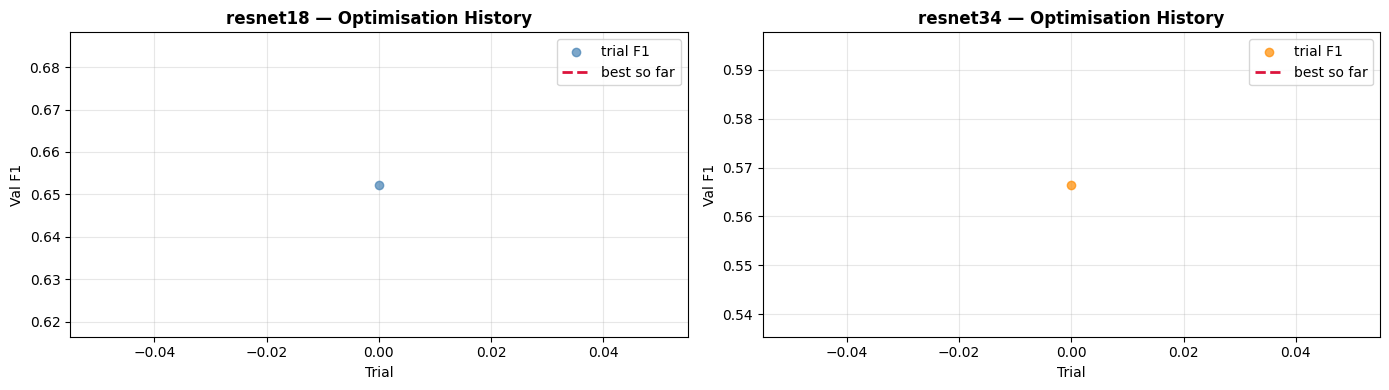

In [20]:
colors = {"resnet18": "steelblue", "resnet34": "darkorange"}
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, study) in zip(axes, studies.items()):
    completed = [t for t in study.trials if t.value is not None]
    nums   = [t.number for t in completed]
    values = [t.value  for t in completed]
    best_so_far = [max(values[:i+1]) for i in range(len(values))]

    ax.scatter(nums, values, color=colors[name], alpha=0.7, zorder=3, label="trial F1")
    ax.plot(nums, best_so_far, color="crimson", linewidth=2, linestyle="--", label="best so far")
    ax.set_title(f"{name} — Optimisation History", fontweight="bold")
    ax.set_xlabel("Trial"); ax.set_ylabel("Val F1")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6 · Final Training with Best Configs

In [21]:
FINAL_EPOCHS = 5   # ↑ to 10–15 for a real run
CLASS_NAMES  = ["Real (wiki)", "Fake (inpainting)"]

final_metrics = {}
final_preds   = {}

for model_name, study in studies.items():
    p = study.best_trial.params
    print(f"\n{model_name}  lr={p['lr']:.2e}  wd={p['weight_decay']:.2e}  bs={p['batch_size']}")

    train_loader, test_loader = make_loaders(p["batch_size"])
    model     = get_model(model_name)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINAL_EPOCHS)

    train_losses, test_accs = [], []
    for epoch in tqdm(range(1, FINAL_EPOCHS + 1), desc=model_name):
        train_one_epoch(model, train_loader, criterion, optimizer)
        _, y_true, y_pred = evaluate(model, test_loader, criterion)
        acc = accuracy_score(y_true, y_pred)
        scheduler.step()
        test_accs.append(acc)

    _, y_true, y_pred = evaluate(model, test_loader, criterion)
    m = compute_metrics(y_true, y_pred)
    final_metrics[model_name] = {"test_accs": test_accs, **m}
    final_preds[model_name]   = (y_true, y_pred)
    print(f"  acc={m['accuracy']:.4f}  prec={m['precision']:.4f}  rec={m['recall']:.4f}  f1={m['f1']:.4f}")


resnet18  lr=1.33e-04  wd=6.35e-03  bs=16


resnet18: 100%|██████████| 5/5 [06:28<00:00, 77.73s/it]


  acc=0.5641  prec=0.5823  rec=0.4539  f1=0.5102

resnet34  lr=1.33e-04  wd=6.35e-03  bs=16


resnet34: 100%|██████████| 5/5 [28:18<00:00, 339.69s/it]


  acc=0.5477  prec=0.5299  rec=0.8454  f1=0.6515


## 7 · Confusion Matrices

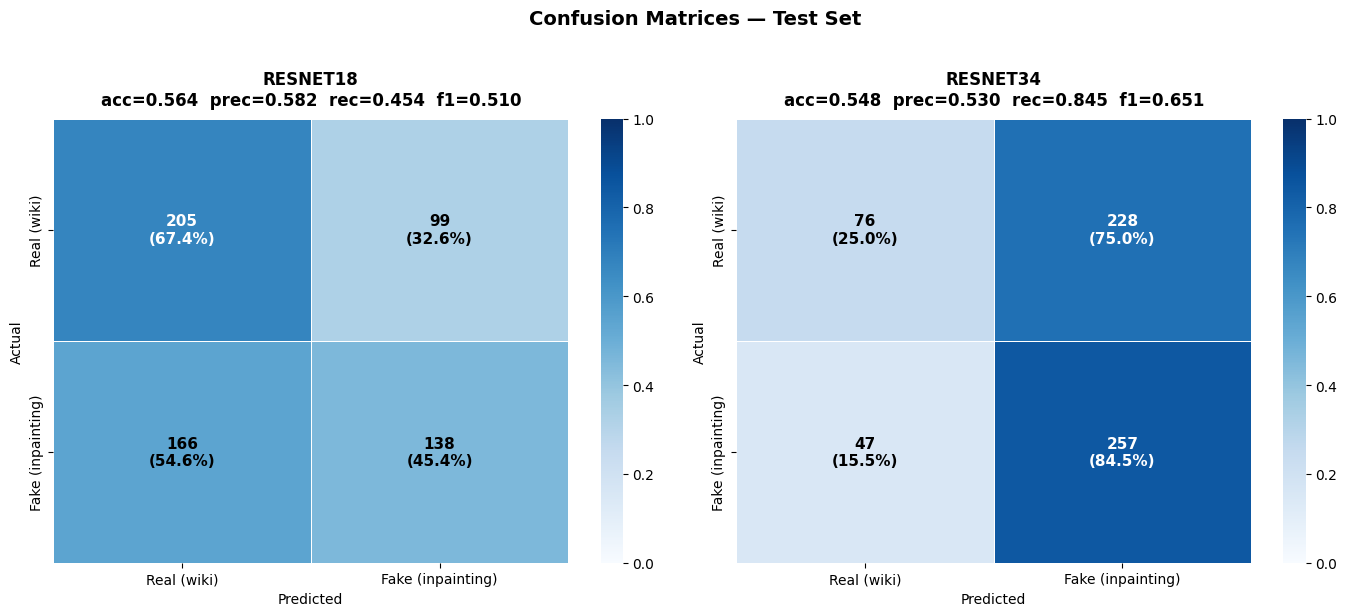

In [22]:
def plot_cm(ax, y_true, y_pred, title):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=False, cmap="Blues",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.5, linecolor="white", ax=ax, vmin=0, vmax=1
    )
    for i in range(2):
        for j in range(2):
            c = "white" if cm_norm[i, j] > 0.55 else "black"
            ax.text(j+0.5, i+0.5, f"{cm[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)",
                    ha="center", va="center", fontsize=11, color=c, fontweight="bold")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, (y_true, y_pred)) in zip(axes, final_preds.items()):
    m = final_metrics[name]
    plot_cm(ax, y_true, y_pred,
            f"{name.upper()}\nacc={m['accuracy']:.3f}  prec={m['precision']:.3f}  rec={m['recall']:.3f}  f1={m['f1']:.3f}")

plt.suptitle("Confusion Matrices — Test Set", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8 · Metrics Summary

In [24]:
for name, (y_true, y_pred) in final_preds.items():
    print(f"\n{'─'*45}  {name.upper()}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


─────────────────────────────────────────────  RESNET18
                   precision    recall  f1-score   support

      Real (wiki)       0.55      0.67      0.61       304
Fake (inpainting)       0.58      0.45      0.51       304

         accuracy                           0.56       608
        macro avg       0.57      0.56      0.56       608
     weighted avg       0.57      0.56      0.56       608


─────────────────────────────────────────────  RESNET34
                   precision    recall  f1-score   support

      Real (wiki)       0.62      0.25      0.36       304
Fake (inpainting)       0.53      0.85      0.65       304

         accuracy                           0.55       608
        macro avg       0.57      0.55      0.50       608
     weighted avg       0.57      0.55      0.50       608



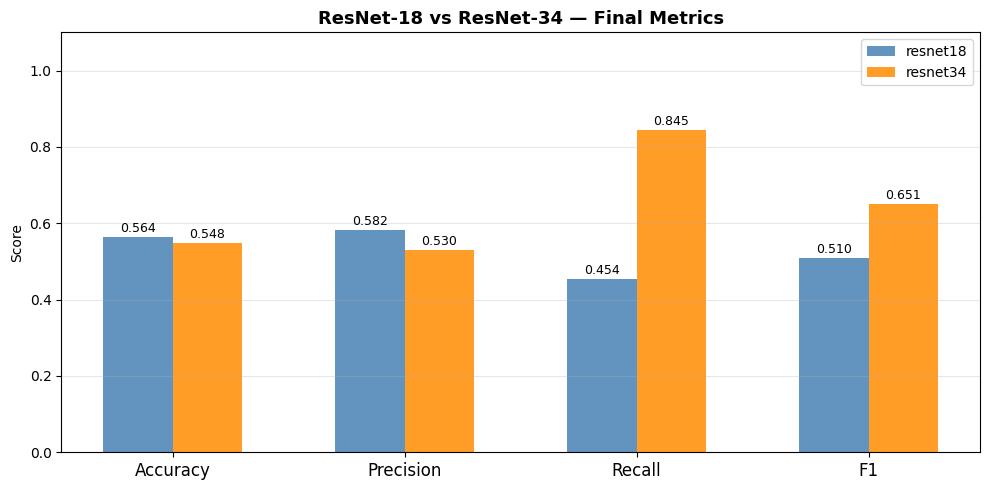

In [23]:
metric_keys = ["accuracy", "precision", "recall", "f1"]
x, width = np.arange(len(metric_keys)), 0.3
fig, ax = plt.subplots(figsize=(10, 5))

for i, name in enumerate(final_metrics):
    vals = [final_metrics[name][k] for k in metric_keys]
    bars = ax.bar(x + i*width, vals, width, label=name, color=list(colors.values())[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x + width/2)
ax.set_xticklabels([k.capitalize() for k in metric_keys], fontsize=12)
ax.set_ylim(0, 1.1); ax.set_ylabel("Score")
ax.set_title("ResNet-18 vs ResNet-34 — Final Metrics", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()